# Going beyond individual feature effects

We apply granite to minimize the disagreements between pure-full feature interactions and joint effects.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from granite.features import Features
from granite.experiments import MinimizeSuperset
from granite.decompositions import get_components_brute_force, get_regional_decompositions

In [36]:
def generate_problem(N, seed, rho_12, rho_14, alpha, beta):
    # Generate input
    np.random.seed(seed)
    cov = np.eye(4)
    cov[0, 1] = rho_12
    cov[1, 0] = rho_12
    cov[0, 3] = rho_14
    cov[3, 0] = rho_14
    X = np.random.multivariate_normal(np.zeros(4), cov=cov, size=(N,))

    # Model to explain
    def f(X):
        return (X[: , 0] + alpha * X[:, 0] * X[:, 1]) * (X[:, 2]>=0).astype(np.int64) +\
               (-X[:, 0] + beta * X[:, 0] * X[:, 3]) * (X[:, 2]<0).astype(np.int64)

    return X, f

# We generate the data and models. The data X is stored in a (N, d) numpy array
X, f = generate_problem(2000, 42, 0, 0, 0.7, 0.7)
features = Features(X, names=[f"x{i}" for i in range(4)], types=["num"]*4)
features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | x0                 | num                | inf        | [0]              |
| 1 | x1                 | num                | inf        | [1]              |
| 2 | x2                 | num                | inf        | [2]              |
| 3 | x3                 | num                | inf        | [3]              |
-------------------------------------------------------------------------------



## Pure-vs-Full feature interaction

We must compute the decomposition with interactions of order 1 and 2.

In [37]:
# B is the empirical distribution over the whole dataset
background = X

# Compute the Interventional Decomposition
decomposition = get_components_brute_force(f, X, X, features, interactions=2, show_bar=True)
display(decomposition.keys())

Functional Decomposition: 4it [00:01,  3.34it/s]
Functional Decomposition: 6it [00:02,  2.07it/s]


dict_keys([(), (0,), (1,), (2,), (3,), (0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)])

In [38]:
# We minimize the pure-full interactions involving features x0 and x1
U = [(0, 1)]
features_to_split_upon = [2, 3]
tree = MinimizeSuperset(features.select(features_to_split_upon), max_depth=2, save_losses=True, branching_per_node=2, alpha=0.1)
tree.fit(X[:, features_to_split_upon], decomposition, U=U)
tree.print(verbose=True)

Loss 1.0544
Samples 2000
If x2 ≤ 0.0221:
|   Loss 0.0315
|   Samples 1050
|   Region 0
else:
|   Loss 0.0000
|   Samples 950
|   Region 1
Final Loss 0.0315


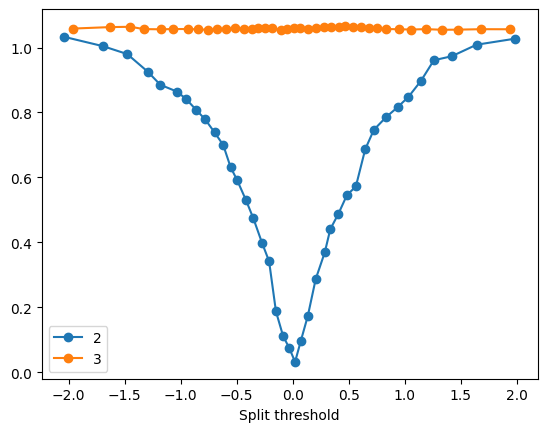

In [39]:
plt.figure()
for i in range(2):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i+2)
plt.xlabel("Split threshold")
plt.legend()

In [40]:
regions = tree.predict(X[:, features_to_split_upon])
display(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
display(rules)
regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)

array([1, 1, 0, 0, 0, 1, 0, 0, 1, 0], dtype=int32)

{0: 'x2<=0.02', 1: 'x2>0.02'}

(-3.0918466187244302, 2.98865193631985)

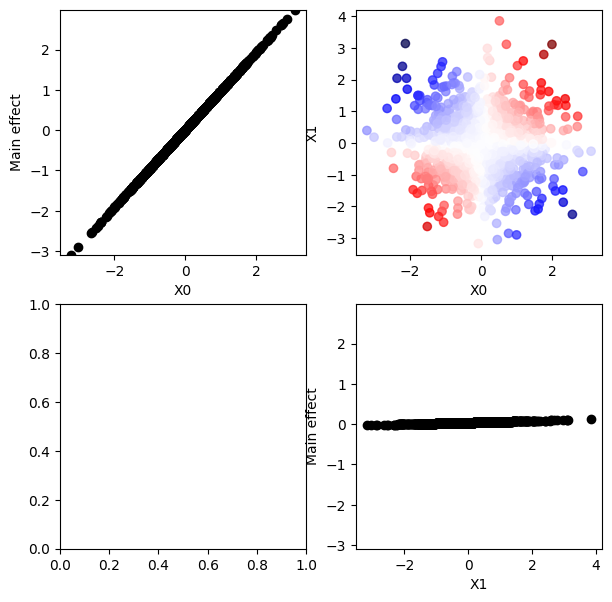

In [41]:
from matplotlib.colors import TwoSlopeNorm

# We plot the pure (0, 1) interaction from `region 1`
main_effect_0 = regional_decompositions[1][(0,)].mean(1)
main_effect_1 = regional_decompositions[1][(1,)].mean(1)
interactions = regional_decompositions[1][(0, 1)].mean(-1),
y_min = min(main_effect_0.min(), main_effect_1.min())
y_max = max(main_effect_0.max(), main_effect_1.max())
fig, axs = plt.subplots(2, 2, figsize=(7, 7))
axs[0, 0].scatter(X[regions==1, 0], main_effect_0, c='k')
axs[0, 0].set_xlabel('X0')
axs[0, 0].set_ylabel('Main effect')
axs[0, 0].set_ylim(y_min, y_max)
axs[0, 1].scatter(X[regions==1, 0], X[regions==1, 1], c=interactions, cmap='seismic', alpha=0.75, norm=TwoSlopeNorm(0))
axs[0, 1].set_xlabel('X0')
axs[0, 1].set_ylabel('X1')
# axs[1, 0].plot(x, -y, 'tab:green')
# axs[1, 0].set_title('Axis [1,0]')
axs[1, 1].scatter(X[regions==1, 1], main_effect_1, c='k')
axs[1, 1].set_xlabel('X1')
axs[1, 1].set_ylabel('Main effect')
axs[1, 1].set_ylim(y_min, y_max)

## Pure-Full joint feature effects

Joint effects are computed as the main effects using a `grouped_features` object, that treats some features as a single group.
Such groups would naturally occur if features are one-hot-encoded, or some features represent a single semantic (e.g. day and month can be
grouped into date). Notice that the new feature group `x0:x1` is not the last last feature to its index is `2`.

In [42]:
grouped_features = features.group([[0, 1]])
grouped_features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | x2                 | num                | inf        | [2]              |
| 1 | x3                 | num                | inf        | [3]              |
| 2 | x0:x1              | num:num            | inf:inf    | [0, 1]           |
-------------------------------------------------------------------------------



In [43]:
# The decomposition is computed as always, while passing the `grouped_features` object instead of `features`
grouped_decomposition = get_components_brute_force(f, X, X, grouped_features)
print(grouped_decomposition.keys())

dict_keys([(), (0,), (1,), (2,)])


In [47]:
U = [(2,)]
# We must use the original index since we split upon ungrouped features
features_to_split_upon = [2, 3]
tree = MinimizeSuperset(features.select(features_to_split_upon), max_depth=2, save_losses=True, branching_per_node=3, alpha=0.2)
tree.fit(X[:, features_to_split_upon], grouped_decomposition, U=U)
tree.print(verbose=True)

Loss 11.5305
Samples 2000
If x2 ≤ 0.0221:
|   Loss 2.3889
|   Samples 1050
|   If x3 ≤ -0.0414:
|   |   Loss 0.8109
|   |   Samples 499
|   |   Region 0
|   else:
|   |   Loss 0.4167
|   |   Samples 551
|   |   Region 1
else:
|   Loss 0.0000
|   Samples 950
|   Region 2
Final Loss 1.2276


In [48]:
regions = tree.predict(X[:, features_to_split_upon])
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
regional_decompositions = get_regional_decompositions(grouped_decomposition, regions, regions, n_regions)
regional_backgrounds = [[]] * n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = X[regions == r]

[2 2 0 0 0 2 1 1 2 1]
{0: '(x2<=0.02 & x3<=-0.04)', 1: '(x2<=0.02 & x3>-0.04)', 2: 'x2>0.02'}


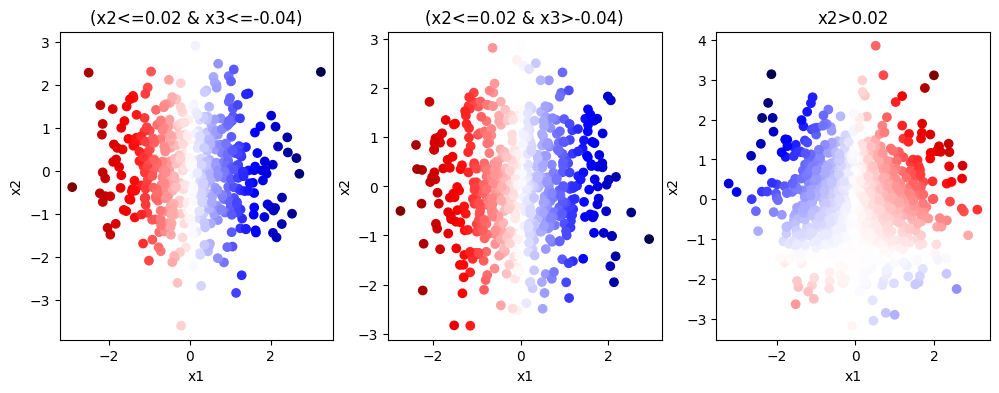

In [49]:
fig, axs = plt.subplots(1, n_regions, figsize=(4 * n_regions, 4))
for r in range(n_regions):
    axs[r].scatter(regional_backgrounds[r][:, 0], regional_backgrounds[r][:, 1], c=regional_decompositions[r][(2,)].mean(-1), cmap='seismic', norm=TwoSlopeNorm(0))
    axs[r].set_xlabel('x1')
    axs[r].set_ylabel('x2')
    axs[r].set_title(rules[r])